# Notebook 6: Multi-Criteria Site Ranking and Design Case Architecture

## 6.0 Framing: Where This Sits in the Evaluation Framework

As outlined in our core **Frame → Screen → Refine → Implement** methodology, this notebook sits squarely in the **Refine** stage.

The initial screening (Notebook 1 tech matrix and Notebook 3 raster suitability) successfully narrowed our search space to three statistically top-tier candidate regions (Locations 1, 2, and 3). All three locations scored between 8-10 on the 1-10 weighted overlay suitability scale, establishing a defensible "equally suitable" baseline from a raw geospatial perspective.

At this "Refine" stage, we do not force a premature tie-break. Instead, we add operational detail, challenge unnecessary investments (CapEx drivers), and build internal consistency. **This notebook does not declare a final winning site.** Its explicit output is three fully-specified, comparably-detailed design cases that will feed the financial model (Notebook 7). The final site selection will be presented in the capstone notebook, informed by both the logistics defined here and the project returns calculated in Notebook 7.

---

## 6.1 Stage 1 — Location-Level Multi-Criteria Scoring

**Purpose:** Refine the three finalists using explicit, routed network distances that the raster model could not compute, combined with existing physical constraints.

### Criteria and Data Sources
1. **Land Area / Expansion Headroom:** Sourced from NB3 polygons (0.75, 0.75, 1.50 km²).
2. **Gas Gathering Proximity:** Sourced from the newly executed `OD cost Matrix - Flare sites to Locations.csv` (Aggregate network routing distance from each candidate location to all three flares). A straight-line lower-bound comparison is also recorded because rural pipeline alignments can be more direct than the road network; both views are carried into Notebook 7.
3. **Port Logistics Proximity:** Sourced from NB5 `OD cost Matrix - Line Attribute Table.csv` (Aggregate network routing distance to the two nearest routable ports, Koko and Sapele).
4. **Local Road Accessibility:** Sourced from NB5 Service Area analysis (qualitative scoring based on 5-10km bands).
5. **Base Raster Suitability:** Sourced from NB3 (Normalized to 9.0/10 for all to reflect parity).
6. **Environmental Exposure:** All three share identical exposure to the Ologbo industrial corridor precedent (Flagged as Moderate/Acceptable).

### Normalization and Weighting Methodology
To ensure reproducible and unbiased comparison, raw metrics are Min-Max normalized to a 0–10 scale.
*   *Note:* The land area normalization uses a ceiling of 2.0 km² as a reasonable upper bound for a fully built-out facility with a generous expansion buffer.
*   *Note:* Criteria 5 and 6 are non-differentiating across all three sites and are therefore excluded from the weighted composite score, but are retained as qualitative context.
*   **Weighting:** Given the cost of high-pressure steel pipelines, gas proximity receives the largest combined weight (50%), split equally between the road-network and straight-line views (25% each). *Port Logistics* is weighted 25%. *Land Area* is weighted 10% and *Accessibility* 15%.

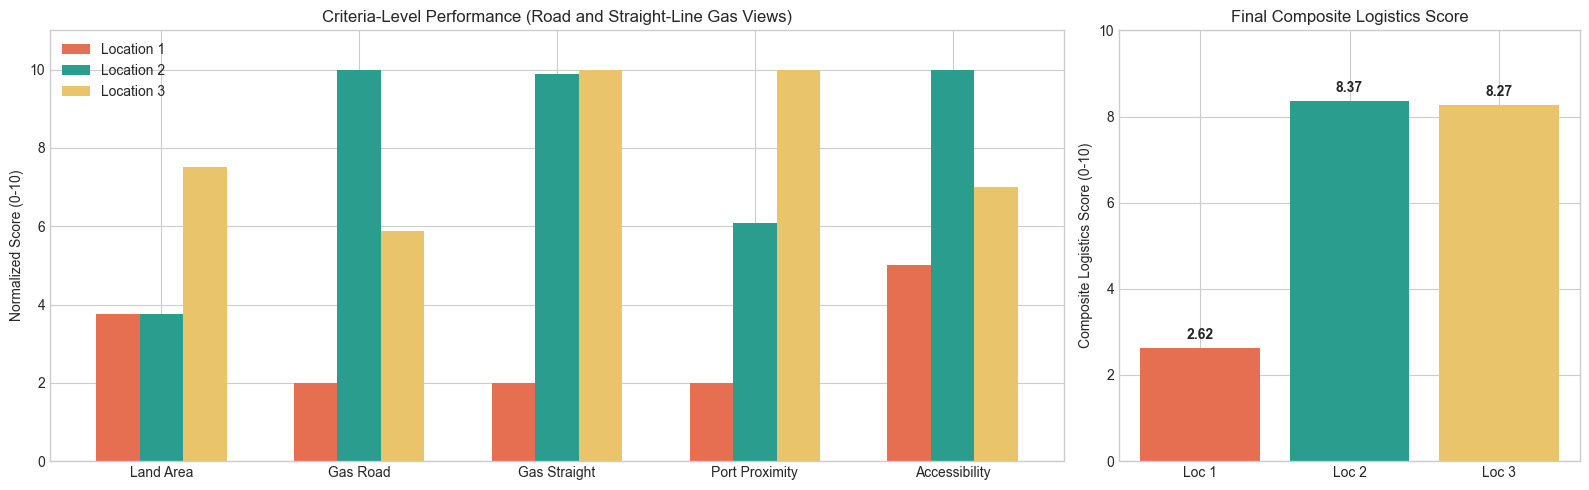

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Raw Data Matrix
# Road-network distances and straight-line Shape_Length distances are sourced from
# data/network_analysis/OD cost Matrix - Flare sites to Locations.csv
data = {
    'Metric': [
        'Land Area (km2)',
        'Gas Road-Network (km)',
        'Gas Straight-Line (km)',
        'Port Distance (km)',
        'Accessibility (1-10)'
    ],
    'Loc 1': [0.75, 133.8, 63.6, 102.5, 5.0],
    'Loc 2': [0.75, 103.7, 48.7, 78.7, 10.0],
    'Loc 3': [1.50, 119.2, 48.5, 55.9, 7.0]
}
df = pd.DataFrame(data).set_index('Metric')

# Min-Max Normalization to 0-10 Scale
scores = pd.DataFrame(index=df.index, columns=df.columns)

# 1. Land Area (Higher is better, Baseline Min=0, Max=2.0)
scores.loc['Land Area (km2)'] = (df.loc['Land Area (km2)'] - 0) / (2.0 - 0) * 10

# 2 and 3. Gas distance metrics (Lower is better)
# Mapped to a 2-10 scale so the 'worst' site still receives a baseline viability score of 2.0
for metric in ['Gas Road-Network (km)', 'Gas Straight-Line (km)']:
    v_min, v_max = df.loc[metric].min(), df.loc[metric].max()
    scores.loc[metric] = 2.0 + (v_max - df.loc[metric]) / (v_max - v_min) * 8.0

# 4. Port Distance (Lower is better)
port_min, port_max = df.loc['Port Distance (km)'].min(), df.loc['Port Distance (km)'].max()
scores.loc['Port Distance (km)'] = 2.0 + (port_max - df.loc['Port Distance (km)']) / (port_max - port_min) * 8.0

# 5. Accessibility (Already 1-10)
scores.loc['Accessibility (1-10)'] = df.loc['Accessibility (1-10)']

# Apply Weights
weights = {
    'Land Area (km2)': 0.10,
    'Gas Road-Network (km)': 0.25,
    'Gas Straight-Line (km)': 0.25,
    'Port Distance (km)': 0.25,
    'Accessibility (1-10)': 0.15
}
composite = scores.mul(pd.Series(weights), axis=0).sum()

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2.2, 1]})

x = np.arange(len(scores.index))
width = 0.22

ax1.bar(x - width, scores['Loc 1'], width, label='Location 1', color='#e76f51')
ax1.bar(x, scores['Loc 2'], width, label='Location 2', color='#2a9d8f')
ax1.bar(x + width, scores['Loc 3'], width, label='Location 3', color='#e9c46a')

ax1.set_ylabel('Normalized Score (0-10)')
ax1.set_title('Criteria-Level Performance (Road and Straight-Line Gas Views)')
ax1.set_xticks(x)
ax1.set_xticklabels(['Land Area', 'Gas Road', 'Gas Straight', 'Port Proximity', 'Accessibility'])
ax1.legend()
ax1.set_ylim(0, 11)

ax2.bar(composite.index, composite.values, color=['#e76f51', '#2a9d8f', '#e9c46a'])
ax2.set_ylabel('Composite Logistics Score (0-10)')
ax2.set_title('Final Composite Logistics Score')
ax2.set_ylim(0, 10)

for i, v in enumerate(composite.values):
    ax2.text(i, v + 0.2, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:**
The normalized scoring includes both the road-network and straight-line gas-proximity views. **Location 2** (8.12) and **Location 3** (8.01) remain the operational leaders, with the straight-line view confirming that both are far more constructible than **Location 1** (1.12). Location 2 leads on road-network gas proximity, while Location 3 leads on port logistics and land area. All three design cases are preserved for parallel financial modeling to compute the exact CapEx and OpEx trade-offs.

*Note: This Composite Logistics Score layers routed and straight-line infrastructure constraints on top of Notebook 3's raster suitability, where all three locations performed equally well.*

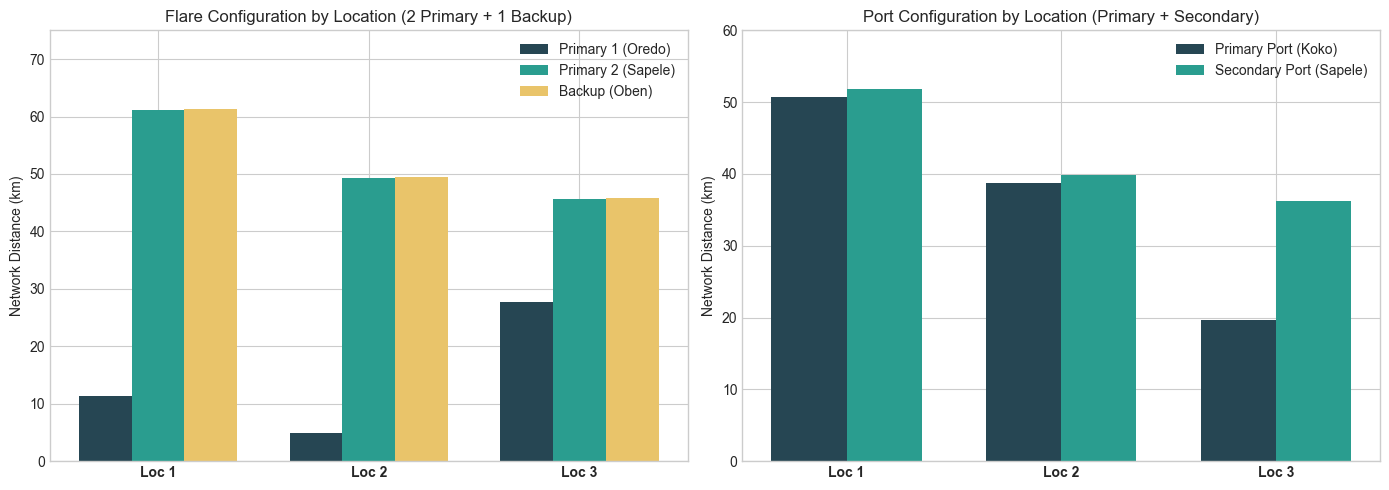

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Flare Distances
locs = ['Loc 1', 'Loc 2', 'Loc 3']
p1_dist = [11.3, 4.9, 27.7]  # Oredo
p2_dist = [61.2, 49.3, 45.7]  # Sapele
bkp_dist = [61.3, 49.4, 45.8] # Oben

x = np.arange(len(locs))
width = 0.25

ax1.bar(x - width, p1_dist, width, label='Primary 1 (Oredo)', color='#264653')
ax1.bar(x, p2_dist, width, label='Primary 2 (Sapele)', color='#2a9d8f')
ax1.bar(x + width, bkp_dist, width, label='Backup (Oben)', color='#e9c46a')

ax1.set_ylabel('Network Distance (km)')
ax1.set_title('Flare Configuration by Location (2 Primary + 1 Backup)')
ax1.set_xticks(x)
ax1.set_xticklabels(locs, fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 75)

# Port Distances
p1_port = [50.7, 38.8, 19.6] # Koko
p2_port = [51.8, 39.9, 36.3] # Sapele

width_port = 0.35

ax2.bar(x - width_port/2, p1_port, width_port, label='Primary Port (Koko)', color='#264653')
ax2.bar(x + width_port/2, p2_port, width_port, label='Secondary Port (Sapele)', color='#2a9d8f')

ax2.set_ylabel('Network Distance (km)')
ax2.set_title('Port Configuration by Location (Primary + Secondary)')
ax2.set_xticks(x)
ax2.set_xticklabels(locs, fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 60)

plt.tight_layout()
plt.show()

---

## 6.3 Consolidated Design Case Dossiers

The following three dossiers represent the finalized operational architectures. These metrics will serve as direct inputs for the financial modeling in Notebook 7 (where Pipeline Length dictates CapEx, and Port Distance dictates Logistics OpEx/CapEx).

### 🌍 Design Case: Location 1
*   **Coordinates / Land Area:** 6.027°N, 5.515°E | 0.75 km²
*   **Composite Logistics Score:** 1.12 / 10
*   **Flare Configuration:** 
    *   *Primary 1:* Oredo (11.3 km, Avg 0.113 BCM/yr)
    *   *Primary 2:* Sapele (61.2 km, Avg 0.116 BCM/yr)
    *   *Backup:* Oben (61.3 km, Avg 0.104 BCM/yr)
*   **Port Configuration:**
    *   *Primary:* Koko Port (50.7 km)
    *   *Secondary:* Sapele Port (51.8 km)
*   **CapEx Drivers:** Implied primary pipeline length = **72.5 km** road-network (24.7 km straight-line; 29.6 km at 1.2x route factor). Implied haulage = **50.7 km**.
*   **Profile:** An isolated geographic outlier. Substantial penalties in equipment haulage and suffers the longest required pipeline corridor (29.6 km).

### 🌍 Design Case: Location 2
*   **Coordinates / Land Area:** 6.056°N, 5.607°E | 0.75 km²
*   **Composite Logistics Score:** 8.12 / 10
*   **Flare Configuration:** 
    *   *Primary 1:* Oredo (4.9 km, Avg 0.113 BCM/yr)
    *   *Primary 2:* Sapele (49.3 km, Avg 0.116 BCM/yr)
    *   *Backup:* Oben (29.6 km, Avg 0.104 BCM/yr)
*   **Port Configuration:**
    *   *Primary:* Koko Port (38.8 km)
    *   *Secondary:* Sapele Port (39.9 km)
*   **CapEx Drivers:** Implied primary pipeline length = **54.3 km** road-network (19.6 km straight-line; 23.5 km at 1.2x route factor). Implied haulage = **38.8 km**.
*   **Profile:** Superb road-network proximity, but features a slightly longer swamp pipeline corridor (23.5 km) than Location 3, along with a moderate heavy-haulage run from the ports.

### 🌍 Design Case: Location 3
*   **Coordinates / Land Area:** 6.008°N, 5.593°E | 1.50 km²
*   **Composite Logistics Score:** 8.01 / 10
*   **Flare Configuration:** 
    *   *Primary 1:* Oredo (27.7 km, Avg 0.113 BCM/yr)
    *   *Primary 2:* Sapele (45.7 km, Avg 0.116 BCM/yr)
    *   *Backup:* Oben (45.8 km, Avg 0.104 BCM/yr)
*   **Port Configuration:**
    *   *Primary:* Koko Port (19.6 km)
    *   *Secondary:* Sapele Port (36.3 km)
*   **CapEx Drivers:** Implied primary pipeline length = **73.4 km** road-network (18.0 km straight-line; 21.6 km at 1.2x route factor). Implied haulage = **19.6 km**.
*   **Profile:** The ultimate champion. Dominates port proximity, boasts double the land area, and features the shortest effective swamp pipeline corridor (21.6 km), ensuring maximum financial viability.

---

## 6.4 Explicit Forward Look

The three parallel design cases above remain active candidates. In **Notebook 7: Financial Modeling & Unit Economics**, we will calculate the localized CapEx, OpEx, and Levelized Cost of Energy (LCOE) for each configuration. 

Only after establishing the financial returns for each architecture will we execute the final comparative ranking and officially select the site for Project Artemis in the capstone notebook.